In [1]:
import pandas as pd
import numpy as np
import scipy

In [2]:
df = pd.read_csv(r'C:\Users\Theo\Project_#3\Data_Science_Project_#3\Data_Science_Project_3\Dataset\weatherAUS.csv',low_memory=False)

In [3]:
df.shape

(145460, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [5]:
df.isna().any()

Date             False
Location         False
MinTemp           True
MaxTemp           True
Rainfall          True
Evaporation       True
Sunshine          True
WindGustDir       True
WindGustSpeed     True
WindDir9am        True
WindDir3pm        True
WindSpeed9am      True
WindSpeed3pm      True
Humidity9am       True
Humidity3pm       True
Pressure9am       True
Pressure3pm       True
Cloud9am          True
Cloud3pm          True
Temp9am           True
Temp3pm           True
RainToday         True
RainTomorrow      True
dtype: bool

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

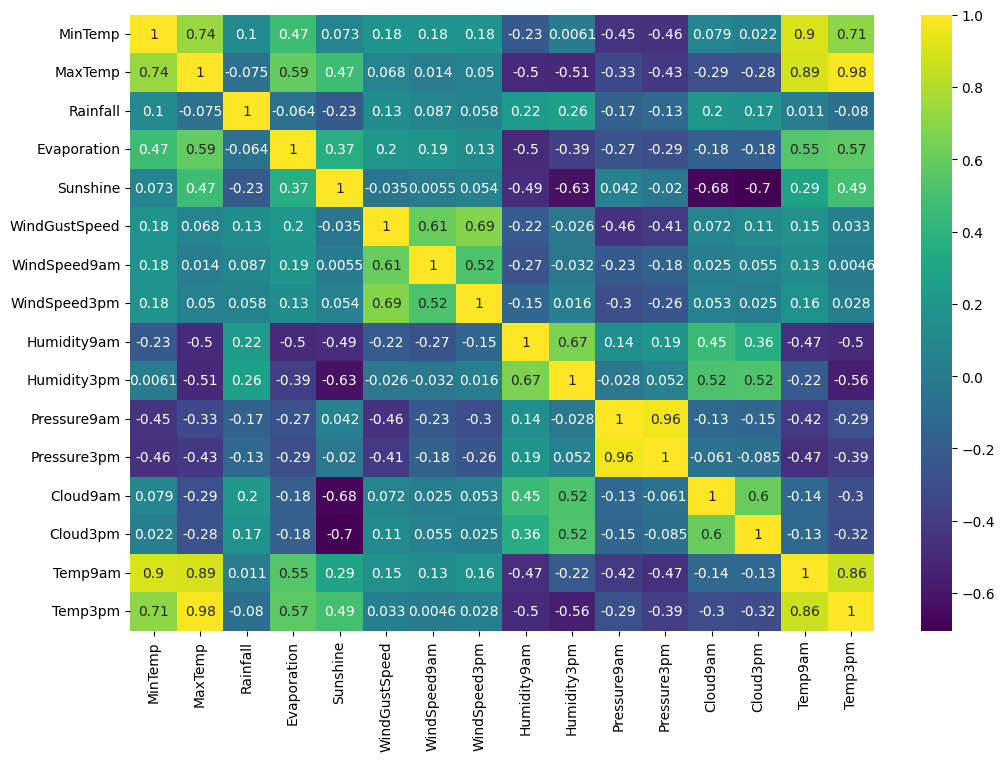

In [7]:
plt.figure(figsize=(12,8))


sns.heatmap(data=df.corr(numeric_only=True), annot=True, cmap='viridis')
plt.show()

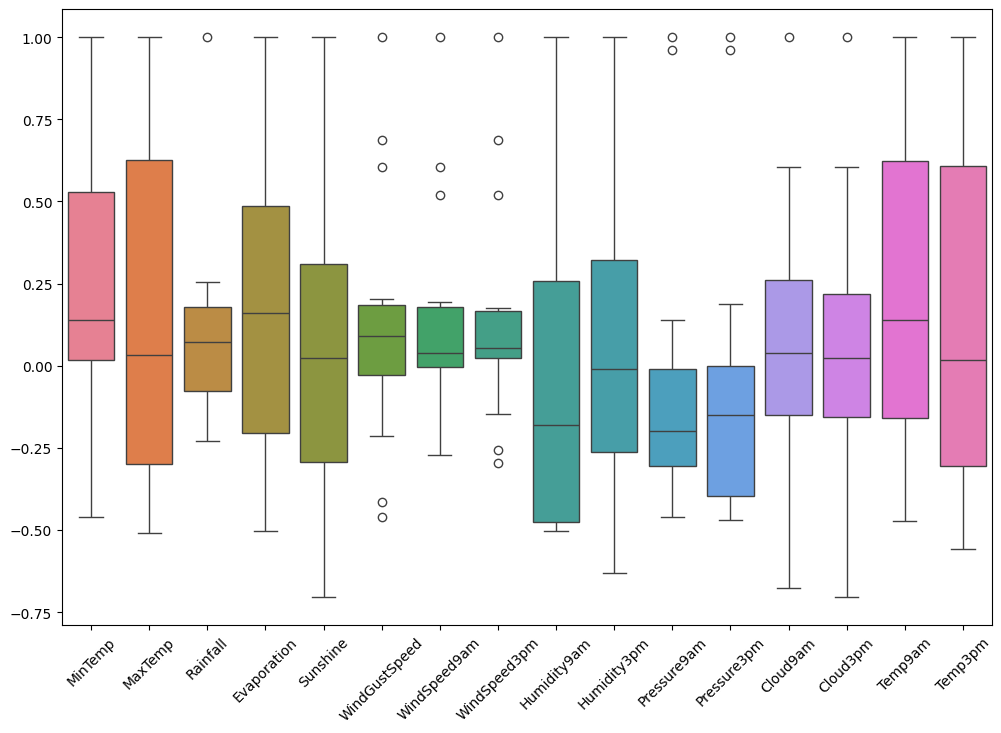

In [8]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.corr(numeric_only=True))
plt.tight_layout
plt.xticks(rotation=45)
plt.show()

In [9]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder

### We are going to predict just the Midday Hours

In [10]:
df['WindGustSpeed'] = df['WindGustSpeed'].interpolate(method='linear')
df['Humidity9am'] = df['Humidity9am'].interpolate(method='linear')
df['Humidity3pm'] = df['Humidity3pm'].interpolate(method='linear')
df['Pressure9am'] = df['Pressure9am'].interpolate(method='linear')
df['Pressure3pm'] = df['Pressure3pm'].interpolate(method='linear')
df['Cloud9am'] = df['Cloud9am'].interpolate(method='linear')
df['Cloud3pm'] = df['Cloud3pm'].interpolate(method='linear')
df['Temp9am'] = df['Temp9am'].interpolate(method='linear')
df['Temp3pm'] = df['Temp3pm'].interpolate(method='linear')
df['Evaporation'] = df['Evaporation'].interpolate(method='linear')
df['Sunshine'] = df['Sunshine'].interpolate(method='linear')
df['WindSpeed9am'] = df['WindSpeed9am'].interpolate(method='linear')
df['WindSpeed3pm'] = df['WindSpeed3pm'].interpolate(method='linear')

In [11]:
df1 = df.copy()

In [12]:
df.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation       6049
Sunshine          6049
WindGustDir      10326
WindGustSpeed        0
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am             0
Cloud3pm             2
Temp9am              0
Temp3pm              0
RainToday         3261
RainTomorrow      3267
dtype: int64

In [13]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

In [14]:
df1.drop(['Rainfall', 'RainToday', 'MaxTemp', 'WindDir9am', 'WindDir3pm'], axis=1, inplace=True)

In [15]:
df1.dropna(subset=['RainTomorrow'], inplace=True)
df1.dropna(subset=['Cloud3pm'], inplace=True)
df1.dropna(subset=['MinTemp'], inplace=True)
df1.dropna(subset=['Evaporation'], inplace=True)
df1.dropna(subset=['Sunshine'], inplace=True)
df1.dropna(subset=['WindGustDir'], inplace=True)

In [16]:
df1["Date"] = pd.to_datetime(df1["Date"])
df1["Month"] = df1["Date"].dt.month

In [17]:
df1.head()

,Date,Location,MinTemp,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow,Month
6049,2009-01-01,Cobar,17.9,12.0,12.3,SSW,48.0,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,1
6050,2009-01-02,Cobar,18.4,14.8,13.0,S,37.0,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,1
6051,2009-01-03,Cobar,15.5,12.6,13.3,SE,30.0,24.5,7.0,36.0,7.0,1012.6,1011.6,1.0,1.0,24.5,32.7,No,1
6052,2009-01-04,Cobar,19.4,10.8,10.6,NNE,46.0,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,1
6053,2009-01-05,Cobar,21.9,11.4,12.2,WNW,31.0,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,1


In [18]:
df1['WindSpeed'] = (df1['WindSpeed9am'] + df1['WindSpeed3pm']) / 2
df1['Humidity']  = (df1['Humidity9am'] + df1['Humidity3pm']) / 2
df1['Pressure'] = (df1['Pressure9am'] + df1['Pressure3pm']) /2 
df1['Cloud'] = (df1['Cloud9am'] + df1['Cloud3pm']) /2
df1['Temperature'] = (df1['Temp9am'] + df1['Temp3pm']) / 2

In [19]:
df1.drop(['WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', \
        'Temp9am','Temp3pm' ], axis=1, inplace=True)

In [20]:
df1.head()

,Date,Location,MinTemp,Evaporation,Sunshine,WindGustDir,WindGustSpeed,RainTomorrow,Month,WindSpeed,Humidity,Pressure,Cloud,Temperature
6049,2009-01-01,Cobar,17.9,12.0,12.3,SSW,48.0,No,1,13.00,16.5,1005.35,3.5,30.00
6050,2009-01-02,Cobar,18.4,14.8,13.0,S,37.0,No,1,19.00,19.0,1012.50,1.0,23.65
6051,2009-01-03,Cobar,15.5,12.6,13.3,SE,30.0,No,1,15.75,21.5,1012.10,1.0,28.60
6052,2009-01-04,Cobar,19.4,10.8,10.6,NNE,46.0,No,1,22.50,32.0,1010.75,3.5,31.80
6053,2009-01-05,Cobar,21.9,11.4,12.2,WNW,31.0,No,1,6.00,29.5,1010.90,3.0,32.35


In [21]:
df1.reset_index(drop=True,inplace=True)

In [22]:
#df1.drop('index',axis=1,inplace=True)

In [23]:
df2 = df1.copy()

In [24]:
df2.drop(['Date', 'Location'], axis=1, inplace=True)

In [25]:
df2.drop('WindGustDir', axis=1, inplace=True)

In [26]:
df2['RainTomorrow'] = df2['RainTomorrow'].map({'Yes':1, 'No':0})

In [27]:
df2['Month'] = df2['Month'].astype(str)

In [28]:
df_dummies = pd.get_dummies(df2['Month'], drop_first=True)

In [29]:
bool_cols = df_dummies.select_dtypes(include="bool").columns
df_dummies[bool_cols] = df_dummies[bool_cols].astype(int)

In [30]:
df_final = df2.join(df_dummies, how="left")

In [31]:
df_final.drop('Month', axis=1, inplace=True)

### We are going to predict if its rainy the next day

In [32]:
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [33]:
X = df_final.drop('RainTomorrow', axis=1)
y = df_final['RainTomorrow']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=10)

In [35]:
pipe = Pipeline([
    ('Scaler', StandardScaler()),
    ('Smote', SMOTE()),
    ('Classifier', LogisticRegression(max_iter=3000))
])

In [36]:
pipe.fit(X_train, y_train)

,steps,"[('Scaler', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,None
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'


In [37]:
y_pred = pipe.predict(X_test)

In [38]:
from sklearn.metrics import classification_report 

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84     24600
           1       0.50      0.77      0.60      7086

    accuracy                           0.78     31686
   macro avg       0.71      0.77      0.72     31686
weighted avg       0.83      0.78      0.79     31686



In [40]:
results = classification_report(y_test, y_pred, output_dict=True)

In [41]:
results_df = pd.DataFrame(results).transpose()
results_df

,precision,recall,f1-score,support
0,0.920413,0.778984,0.843813,24600.000000
1,0.499632,0.766159,0.604835,7086.000000
accuracy,0.776116,0.776116,0.776116,0.776116
macro avg,0.710022,0.772571,0.724324,31686.000000
weighted avg,0.826313,0.776116,0.790370,31686.000000


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [43]:
pipe1 = Pipeline([
    ('Scaler', StandardScaler()),
    ('Smote', SMOTE()),
    ('Classifier', GradientBoostingClassifier(n_estimators=500, min_samples_split=4))
])

In [44]:
pipe1.fit(X_train, y_train)

,steps,"[('Scaler', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,None
,k_neighbors,5
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'


In [45]:
y_pred1 = pipe.predict(X_test)

In [46]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84     24600
           1       0.50      0.77      0.60      7086

    accuracy                           0.78     31686
   macro avg       0.71      0.77      0.72     31686
weighted avg       0.83      0.78      0.79     31686



In [47]:
pipe2 = Pipeline([
    ('Scaler', StandardScaler()),
    ('Smote', SMOTE()),
    ('Classifier', RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_split=3))
])

In [48]:
pipe2.fit(X_train, y_train)

,steps,"[('Scaler', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,None
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500


In [49]:
y_pred2 = pipe.predict(X_test)

In [50]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84     24600
           1       0.50      0.77      0.60      7086

    accuracy                           0.78     31686
   macro avg       0.71      0.77      0.72     31686
weighted avg       0.83      0.78      0.79     31686



In [52]:
from sklearn.metrics import confusion_matrix

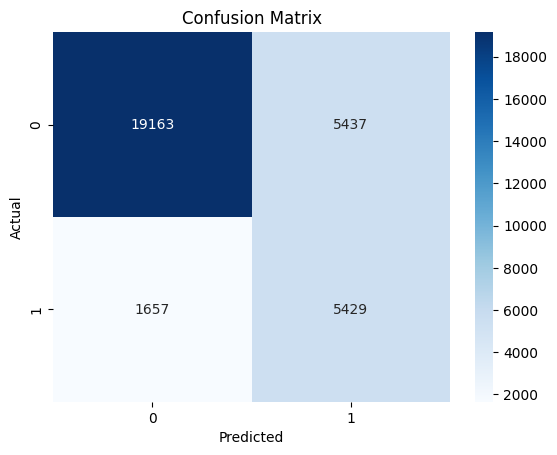

In [53]:
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()